# **<center> 4D-CE2 Data et Transport**
# **TD1 Driver Behavior Detection**

We will work with driving data and uncover insights about road safety.
Analyzing and interpreting driving data help to identify typical driving behaviors such as speeding, rapid acceleration, and sudden braking, etc.

Using information about these patterns, we can evaluate driver behavior, detect risky maneuvers, and develop strategies to enhance road safety such as identifying accident-prone areas, designing smarter alert systems, or improving autonomous vehicle decision-making.

The dataset is collected using on-board sensors, specifically an **accelerometer** and a **gyroscope**, each capturing motion in three dimensions. The accelerometer measures linear acceleration along the X, Y, and Z axes in meters per second squared (m/s²), while the gyroscope records angular velocity along the same axes in degrees per second (°/s).

Here is **the link to download the dataset**, we will use only one csv file, i.e. features_14.csv

(**Files --> Features By Window Size -->  features_14.csv**) :
https://data.mendeley.com/datasets/jj3tw8kj6h/2



In the raw dataset, driving signals are sampled twice per second. Rather than relying on raw data points, the signals are segmented into windows of varying lengths. Each window provides a temporal snapshot, rich enough to capture the context of driving behavior. This approach is crucial: a single speed or acceleration reading tells us little about intent, but a sequence over a short period can reveal whether a maneuver qualifies as a sudden brake, a harsh acceleration, or simply normal driving. The window must be carefully balanced:
* short enough to detect sharp events,
* long enough to encompass the full motion pattern.

By summarizing each window with statistical features such as *mean, covariance, minimum, and maximum*, we gain a compact and interpretable representation of driving attitudes that raw data alone could never provide.

## **1. Libraries and Data Upload**

Let's begin by importing the librairies we'll need to work

In [105]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [106]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.activations import relu, softmax

Now, we'll import our dataset into Colab <br>

If you save the data file in your drive, you can use `drive.mount` to access your drive and then read the file. Otherwise, you can use `files.upload` to select the file anywhere in your computer.

**1st option:** upload the data via `drive.mount`

Connects your entire Google Drive to the Colab environment.

✅ Pros:

- Gives access to all your files and folders in Drive, not just a single upload.

- Allows you save outputs back to Drive (great for storing models, datasets, or reports).

⚠️ Cons:

- Requires authorization, meaning Colab will ask for permission to access your Drive.

✨ When to use: Perfect if you need to work with multiple files, large datasets, or entire folders. Better also if you will rerun notebooks often (persistent storage), while manual upload is only temporary.


In [107]:
# Read the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("/home/sable/Documents/data et transport/features_14.csv")  # MODIFY THE PATH AFTER MyDrive/ ACCORDING TO YOUR OWN PATH!


**2nd option:** upload the data via `files.upload`

Allows you manually upload one or more files directly into the Colab session’s temporary storage.

✅ Pros

- Quick and simple for a single file or small uploads.

- No need to grant Colab access to your Drive.

⚠️ Cons

- Not convenient for managing multiple files or saving outputs permanently.

✨ When to use: Best for one-off uploads, like a single dataset or script you just need temporarily.


In [108]:
# Read the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("features_14.csv")

## **2. Data Exploration**

Display:

1. a few `head` lines on our dataset
2. `describe` each column with descriptive statistics
3. number of rows and columns (`shape` of the dataset)

In [109]:
print(df.head())

   Target  AccMeanX  AccMeanY  AccMeanZ   AccCovX   AccCovY   AccCovZ  \
0       1  0.285339 -0.138611 -0.957764  0.022150  0.003975  0.001926   
1       1  0.313477 -0.161670 -0.956250  0.020571  0.005640  0.001456   
2       1  0.325195 -0.158325 -0.950155  0.017281  0.004579  0.001388   
3       1  0.336565 -0.172468 -0.937640  0.015305  0.005216  0.002253   
4       1  0.337860 -0.164185 -0.941681  0.013132  0.005020  0.002062   

   AccSkewX  AccSkewY  AccSkewZ  ...  GyroMaxZ  GyroVarX  GyroVarY  GyroVarZ  \
0  0.867594 -1.305868 -0.507254  ...  0.832061  0.761120  0.184372  0.262859   
1  0.002474 -0.395088 -0.677572  ...  0.832061  3.061080  0.585991  0.270340   
2 -0.354212 -0.603657 -0.984635  ...  0.832061  3.137076  0.552431  0.905518   
3 -0.655653 -0.152454 -0.040530  ...  0.832061  2.809524  3.963056  0.893127   
4 -0.718488 -0.446061  0.250539  ...  0.832061  2.667567  3.414394  0.799787   

   GyroMedianX  GyroMedianY  GyroMedianZ  GyroStdX  GyroStdY  GyroStdZ  
0    -0

In [110]:
df.describe()

,Target,AccMeanX,AccMeanY,AccMeanZ,AccCovX,AccCovY,AccCovZ,AccSkewX,AccSkewY,AccSkewZ,...,GyroMaxZ,GyroVarX,GyroVarY,GyroVarZ,GyroMedianX,GyroMedianY,GyroMedianZ,GyroStdX,GyroStdY,GyroStdZ
count,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,...,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000
mean,2.490018,0.250681,-0.094582,-0.983306,0.029196,0.030323,0.009583,-0.112822,-0.099898,-0.186448,...,13.362845,11.155935,10.381491,114.428756,-0.735789,4.211808,1.109295,3.142812,3.034641,8.206899
std,1.050665,0.080183,0.091875,0.026849,0.022935,0.022036,0.006485,0.698375,1.056449,0.892163,...,16.113840,7.374181,7.085781,115.341708,0.844474,0.844673,1.514056,1.131295,1.083287,6.864279
min,1.000000,0.019642,-0.309535,-1.053659,0.000042,0.000070,0.000118,-2.694572,-3.429108,-3.073868,...,0.832061,0.053027,0.030970,0.026300,-4.061069,-0.736641,-15.675573,0.230276,0.175983,0.162173
25%,2.000000,0.196429,-0.166037,-1.003257,0.012777,0.007605,0.004619,-0.558205,-0.866926,-0.781039,...,2.389313,5.376291,5.239952,1.246986,-1.084924,3.779580,0.759542,2.318683,2.289094,1.116685
50%,3.000000,0.254752,-0.114406,-0.984262,0.022769,0.031239,0.008100,-0.135493,-0.123392,-0.124783,...,4.625954,9.686863,8.728437,127.534036,-0.660305,4.297710,1.019084,3.112373,2.954393,11.293095
75%,3.000000,0.309457,-0.007616,-0.964587,0.034529,0.045968,0.012561,0.205514,0.774952,0.350263,...,32.601145,14.986955,13.725827,217.342978,-0.347328,4.747137,1.427481,3.871299,3.704838,14.742556
max,4.000000,0.445452,0.114851,-0.900652,0.109354,0.094144,0.030886,3.321394,2.504595,3.356136,...,45.442748,39.778734,35.373877,379.616823,3.358779,6.500000,9.721374,6.307038,5.947594,19.483758


In [111]:
df.shape

(1102, 61)

There are 61 columns and 1102 observations (rows) in total.



You will see the `columns` names in detail and ***type*** of each column.

We see that our data are just composed of floats, except the ***Target*** variable which is integer.

Now, we want to check if there are any missing values in the dataset (using `is.na()`) and if it needs some cleaning. Think about how you can determine the number of missing values in each column.

In [112]:
df.isna().sum()

Target         0
AccMeanX       0
AccMeanY       0
AccMeanZ       0
AccCovX        0
              ..
GyroMedianY    0
GyroMedianZ    0
GyroStdX       0
GyroStdY       0
GyroStdZ       0
Length: 61, dtype: int64

In [113]:
df.isna().sum().sum()

np.int64(0)

There is no missing values.

In [114]:
df.dtypes

Target           int64
AccMeanX       float64
AccMeanY       float64
AccMeanZ       float64
AccCovX        float64
                ...   
GyroMedianY    float64
GyroMedianZ    float64
GyroStdX       float64
GyroStdY       float64
GyroStdZ       float64
Length: 61, dtype: object

In [115]:
# Colonnes et types
print(f"Nombre de colonnes : {len(df.columns)}")
print("\nDtypes :")
print(df.dtypes)

# Distribution des classes (trouver colonne cible)
print("\nColonnes du DataFrame :")
print(df.columns.tolist())

# Chercher la colonne cible
target_candidates = ['Target', 'target', 'Type', 'type']
target_col = None
for c in target_candidates:
    if c in df.columns:
        target_col = c
        break

if target_col:
    print(f"\nColonne cible trouvée : {target_col}")
    print("\nDistribution des classes :")
    display(df[target_col].value_counts())
else:
    print("Aucune colonne cible détectée. Colonnes disponibles :", df.columns.tolist())

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df.isna().sum().sum(), "au total")

Nombre de colonnes : 61

Dtypes :
Target           int64
AccMeanX       float64
AccMeanY       float64
AccMeanZ       float64
AccCovX        float64
                ...   
GyroMedianY    float64
GyroMedianZ    float64
GyroStdX       float64
GyroStdY       float64
GyroStdZ       float64
Length: 61, dtype: object

Colonnes du DataFrame :
['Target', 'AccMeanX', 'AccMeanY', 'AccMeanZ', 'AccCovX', 'AccCovY', 'AccCovZ', 'AccSkewX', 'AccSkewY', 'AccSkewZ', 'AccKurtX', 'AccKurtY', 'AccKurtZ', 'AccSumX', 'AccSumY', 'AccSumZ', 'AccMinX', 'AccMinY', 'AccMinZ', 'AccMaxX', 'AccMaxY', 'AccMaxZ', 'AccVarX', 'AccVarY', 'AccVarZ', 'AccMedianX', 'AccMedianY', 'AccMedianZ', 'AccStdX', 'AccStdY', 'AccStdZ', 'GyroMeanX', 'GyroMeanY', 'GyroMeanZ', 'GyroCovX', 'GyroCovY', 'GyroCovZ', 'GyroSkewX', 'GyroSkewY', 'GyroSkewZ', 'GyroSumX', 'GyroSumY', 'GyroSumZ', 'GyroKurtX', 'GyroKurtY', 'GyroKurtZ', 'GyroMinX', 'GyroMinY', 'GyroMinZ', 'GyroMaxX', 'GyroMaxY', 'GyroMaxZ', 'GyroVarX', 'GyroVarY', 'GyroVarZ', 'GyroM

Target
3    347
2    285
1    249
4    221
Name: count, dtype: int64


Valeurs manquantes :
0 au total


## **3. Data Preprocessing**



### **3.1. Missing values**

There is likely no cleaning or data replacing needed for us to operate our modeling.

### **3.2. Define X and y**

You will select the explicative features and target. You can `drop` Target variable for X.

In [116]:
y = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

### **3.3. Data split**

We simply split training and testing dataset with percentages of 80% and 20%, respectively.

In neural network models, we need a validation set since they are more prone to overfitting. However, classical ML models -like kNN, SVM, RF, etc.- do not have lots of hyperparameters. So, in practice, instead of holding out a separate validation set, we often use k-fold cross-validation for these models.

For this example, we will not go in detail on cross-validation and use simply training and test set without validation set.

Thus, you will split the data into training and test using `train_test_split` with test size 0.2.

(Use `random_state = 42`)

In [117]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### **3.4. Standardization**

Since we do not have missing values, we can continue directly with data transformation. Here we have all numeric values for features, so that we can standardise them in order to avoid the dominance of large-range features (like GyroVarZ).

Now:
1. Create a scaler using `StandardScaler()`
2. `fit` the scaler on X_train (learn mean and std from training data only)
3. `transform` X_train using those learned values
4. `transform` X_test with the same scaler (without refitting)

In [118]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
print("Shapes après split et scaling :")
print(f"X_train : {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")

Shapes après split et scaling :
X_train : (881, 60)
X_test : (221, 60)
y_train : (881,)
y_test : (221,)


## **4. Driver Behavior Classification using kNN**

### **4.1. Labels**

Now you will check `unique` y values.

In [120]:
y.unique()


array([1, 2, 3, 4])

In [121]:
y.value_counts().sort_index()

Target
1    249
2    285
3    347
4    221
Name: count, dtype: int64

In [122]:

print("\nProportions (en %) :")
display((y.value_counts(normalize=True) * 100).sort_index().round(2))


Proportions (en %) :


Target
1    22.60
2    25.86
3    31.49
4    20.05
Name: proportion, dtype: float64

These labels belong to different driving behaviors:


1.   Sudden Acceleration (Class Label: 1),
2.   Sudden Right Turn (Class Label: 2),
3.   Sudden Left Turn (Class Label: 3),
4.   Sudden Break (Class Label: 4)




Check the proportion of each class in the dataset to see if we have a balanced dataset or not.

In [123]:
# 4.1 Distribution des classes

proportions = (y.value_counts(normalize=True).sort_index() * 100)
print("="*70)
print("\n1. Sudden Acceleration (Class Label: 1), {:.2f}%".format(proportions[1]))
print("2. Sudden Right Turn (Class Label: 2), {:.2f}%".format(proportions[2]))
print("3. Sudden Left Turn (Class Label: 3), {:.2f}%".format(proportions[3]))
print("4. Sudden Brake (Class Label: 4), {:.2f}%".format(proportions[4]))




1. Sudden Acceleration (Class Label: 1), 22.60%
2. Sudden Right Turn (Class Label: 2), 25.86%
3. Sudden Left Turn (Class Label: 3), 31.49%
4. Sudden Brake (Class Label: 4), 20.05%


Each class appears in similar proportions, suggesting that the dataset is **balanced**.

**Dataset ÉQUILIBRÉ**

### **4.2. Applying the kNN**

Generally, supervised ML algorithms follow a similar workflow:

1.   Initializing the algorithm with its hyperparameters

    from relatedlibrary import theMethod
    your_model = theMethod(theHyperparametersWithTheirValues)

2.   Fitting it using training dataset with labels

    your_model.fit(X_train, y_train)

3.   Predicting the labels of testing dataset

    y_pred = your_model.predict(X_test)

4.   Comparing the true labels of testing dataset with the predicted ones to calculate the performance indicators (e.g. accuracy for classification, MSE for regression, etc.)

    accuracy_score(y_test, y_pred)
    mean_squared_error(y_test, y_pred)

etc.

Now, let's do it for kNN classification.


In [124]:
# Créer et entraîner le modèle kNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prédictions
y_pred = knn.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"kNN Accuracy : {acc:.4f} ({acc*100:.2f}%)")

# Classification report
print("\nClassification Report :")
print(classification_report(y_test, y_pred))

kNN Accuracy : 0.9910 (99.10%)

Classification Report :
              precision    recall  f1-score   support

           1       0.98      1.00      0.99        50
           2       1.00      0.98      0.99        57
           3       1.00      0.99      0.99        70
           4       0.98      1.00      0.99        44

    accuracy                           0.99       221
   macro avg       0.99      0.99      0.99       221
weighted avg       0.99      0.99      0.99       221



Classification Report :
              precision    recall  f1-score   support

           1       0.98      1.00      0.99        50
           2       1.00      0.98      0.99        57
           3       1.00      0.99      0.99        70
           4       0.98      1.00      0.99        44

    accuracy                           0.99       221
   macro avg       0.99      0.99      0.99       221
weighted avg       0.99      0.99      0.99       221



**Confusion matrix** shows how the predictions of the model compare to the true labels. It tells you how many predictions were correct, and where the model made mistakes.

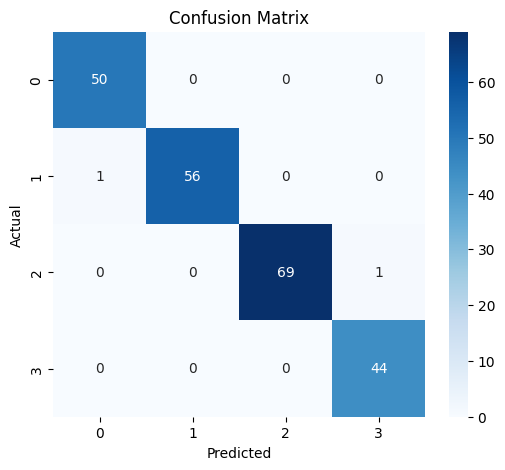

In [125]:
# Compute the confusion matrix to compare true vs predicted labels
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **5. Driver Behavior Classification using CNN**



### **5.1. Encoding labels**

While classical ML models for classification may work on numeric labels, deep neural networks require encoded labels to treat easily in neural networks. Hence, we will firstly convert our numeric labels into one-hot encoded variables, using `to_categorical`.
- You first need to get labels starting from 0 (to 3 in this case since there are 4 classes) (remember that the current range is between 1 and 4)
- Then convert them using `to_categorical` (do not forget to give num_classes as an argument)

In [126]:
X_all = X.values
y_all = y.values

# Étape 1 : 60% train, 40% temp
X_train_c, X_temp, y_train_c, y_temp = train_test_split(
    X_all, y_all, test_size=0.4, random_state=42, stratify=y_all
)

# Étape 2 : Split temp en valid/test (50/50 du 40%)
X_valid_c, X_test_c, y_valid_c, y_test_c = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"X_train : {X_train_c.shape}  → 60%")
print(f"X_valid : {X_valid_c.shape}  → 20%")
print(f"X_test : {X_test_c.shape}   → 20%")

X_train : (661, 60)  → 60%
X_valid : (220, 60)  → 20%
X_test : (221, 60)   → 20%


### **5.2. Data split**

Proper data splitting is crucial to evaluate model performance reliably. The validation set helps tune hyperparameters especially in neural networks, such as CNN. Let's split training, validation and testing dataset with percentages of 60%, 20% and 20%, respectively. For this task, you can use `train_test_split` twice by applying the following steps:

**Step 1**: Create the train set

Test & valid set: 40% of the total dataset as a temporary set (X_temp, y_temp)

Train set: Remaining 60% reserved for training (X_train, y_train)

➝ Result: 60% train, 40% valid+test

**Step 2**: Split valid+test set

Now we split the 40% valid+test into: 20% validation + 20% test

Since this split is on the 40% chunk, we need to take its half for each of them:

Validation = 0.40 × **0.50** = 0.20 (20%)

Test = 0.40 × **0.50** = 0.20 (20%)

➝ Result final split: 60% train, 20% valid, 20% test

In [127]:
# Construction of training, validation and test sets

X_train_c, X_temp, y_train_c, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42, stratify=y_all
)

# Étape 2 : Split temp en valid/test (50/50 du 40%)
X_valid_c, X_test_c, y_valid_c, y_test_c = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [128]:
# Scale features using StandardScaler for new splitted datasets
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_valid_c = scaler.transform(X_valid_c)
X_test_c = scaler.transform(X_test_c)

### **5.3. Build the CNN model**

Now let's build our model for classifying the driver. <br>
We choose to use a basic Convolutional Neural Network, with 2 Convolutional (`Conv1D` since we have tabular data, not an image etc.) layers and 2 fully-connected (`Dense`) layers, and `MaxPooling1D` and `Flatten` operations.<br>
We will also use `Dropout` for regularization.



As a reminder, this is a classification model with 4 classes. This is why the last layer of our model will use the **`softmax`** activation function. The hidden layers use the **`relu`** activation function.
We compile the model using **`categorical_crossentropy`** as a loss and **`adam`** as optimizer. The **`accuracy`** is the metric used during the training.

Complete the code below with the Keras implementation of the following convolutional network:

- Convolutional layer with **64 units**, kernel_size ` 3`, and `'relu'` activation. *Don't forget to set `input_shape`!*
    * Conv1D expects an input in the form of (the number of features except the target variable, 1) where 1 is the single feature channel.
    * Pay attention that kernel_size (and pool_size later) requires one-dimensional value, not (3,3) but just 3 for kernel_size here.
- Max pooling with pool_size `2` downsampling.
- Convolutional layer with **128 units**, kernel_size ` 3`, and `'relu'` activation.
- Max pooling with pool_size `2` downsampling.
- Flatten layer.
- Dense layer with **128 units** and `'relu'` activation.
- Dropout with a rate of 0.5.
- Dense layer with **4 units** and `'softmax'` activation.

In [129]:
n_features = X_train_c.shape[1]  # 60
X_train_c = X_train_c.reshape((X_train_c.shape[0], n_features, 1))
X_valid_c = X_valid_c.reshape((X_valid_c.shape[0], n_features, 1))
X_test_c = X_test_c.reshape((X_test_c.shape[0], n_features, 1))

In [130]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_c)  # [0,1,2,3]
y_valid_enc = le.transform(y_valid_c)
y_test_enc = le.transform(y_test_c)

n_classes = len(le.classes_)  # 4

y_train_cat = to_categorical(y_train_enc, num_classes=n_classes)
y_valid_cat = to_categorical(y_valid_enc, num_classes=n_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=n_classes)

print(f"Nombre de classes : {n_classes}")

Nombre de classes : 4


In [131]:
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(n_features, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(n_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/home/sable/miniconda3/envs/de1-env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       213,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,596 (932.02 KB)

 Trainable params: 238,596 (932.02 KB)

 Non-trainable params: 0 (0.00 B)

Now, we can properly train our model. <br>
We can display the learning curves to make sure the training goes well, and detect cases of overfitting/underfitting.

In [132]:
# Train the model and evaluate performance on the validation set
history = model.fit(X_train_c, y_train_cat, epochs=20, batch_size=64, validation_data=(X_valid_c, y_valid_cat))

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.6747 - loss: 0.9405 - val_accuracy: 0.8636 - val_loss: 0.5003
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.6747 - loss: 0.9405 - val_accuracy: 0.8636 - val_loss: 0.5003
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8608 - loss: 0.4026 - val_accuracy: 0.9273 - val_loss: 0.2198
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8608 - loss: 0.4026 - val_accuracy: 0.9273 - val_loss: 0.2198
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9334 - loss: 0.2171 - val_accuracy: 0.9682 - val_loss: 0.1336
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9334 - loss: 0.2171 - val_accuracy: 0.9682 - val_loss: 0.1336
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9592 - loss: 0.1379 - val_accuracy: 0.9818 - val_loss: 0.0814
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9592 - loss: 0.1379 - val_accuracy: 0.9818 - v

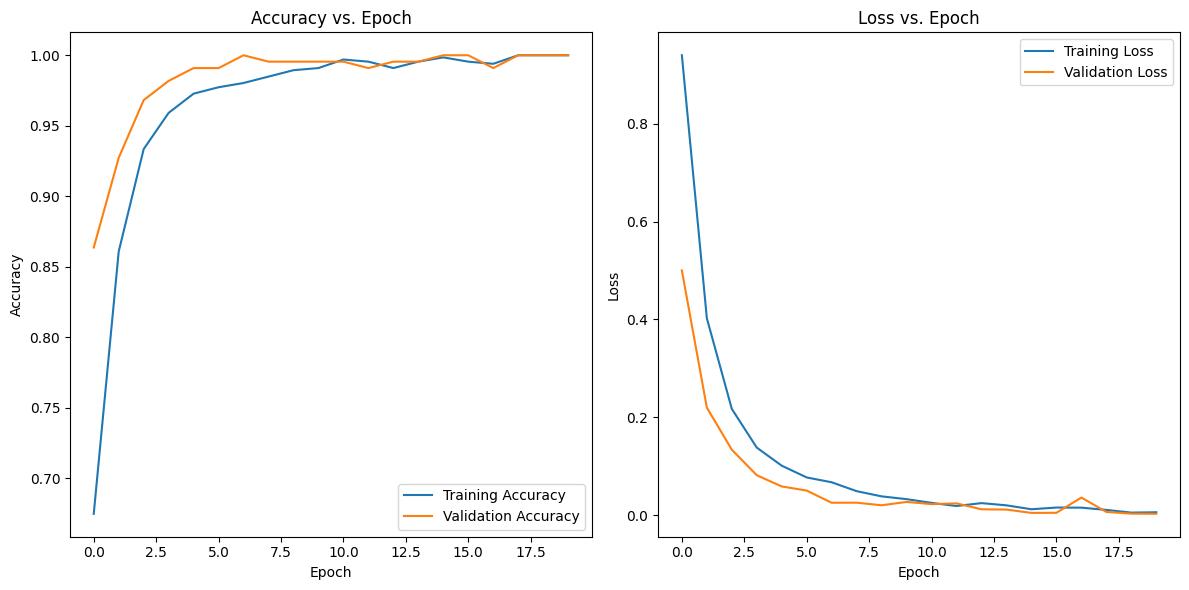

In [133]:
# Drawing of the learning curves
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(train_accuracy))

plt.figure(figsize=(12, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

From these learning curves, there the training likely went very well. <br>
There is apparently neither overfitting nor underfitting.

We will now display the accuracy obtained on the test set.

In [137]:
# Evaluate the trained model on the test set
test_loss, test_acc = model.evaluate(X_test_c, y_test_cat)

print(f'Test accuracy: {test_acc*100:.2f}%')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0023
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0023
Test accuracy: 100.00%
Test accuracy: 100.00%


Let's examine the predictions of our model and display the confusion matrix.

In [138]:
# Model outputs class probabilities for each test point
y_pred_proba = model.predict(X_test_c)

# The class with the highest probability is selected as the prediction
y_pred = y_pred_proba.argmax(axis=1)

# Since y_test was one-hot encoded, we convert it back to class indices
y_test_pred = y_test_cat.argmax(axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


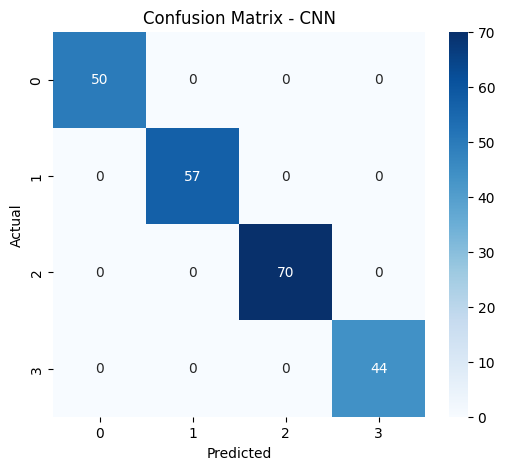

In [139]:
# Compute the confusion matrix to compare true vs predicted labels
cm = confusion_matrix(y_test_pred, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN')
plt.show()

## **6. Comments on the results**

We achieved very good results on the test set, with kNN reaching about 98% accuracy and CNN around 94%. This shows that deep learning is not always the best option. Sometimes simpler models like kNN can perform better, especially on structured tabular data where relationships between features are already well captured without the need for complex feature extraction.

Comparing the confusion matrices, we can see that the CNN struggles to detect class 2, *Sudden Left Turn*. It sometimes misclassifies this behavior as *Sudden Acceleration* or *Sudden Brake*. This issue could be explored further in future work.

CNNs or LSTMs could still be explored in the future, but in this case, the nature of the dataset favors kNN.